# Лабораторная работа №3 (NLP, 3 курс)
## Тема: Оптимизация поиска вакансий по резюме кандидатов

**Цель:** разработать систему, которая по тексту резюме находит наиболее подходящие вакансии. Сравнить классический подход (TF-IDF) с современными векторными представлениями (Word2Vec, Sentence-BERT).

**Методология (по методичке):** предобработка текста → TF-IDF → cosine similarity. Дополнительно — эмбеддинги (Word2Vec, Sentence-BERT).

**Метрики:** Precision@k, Recall@k, MRR, NDCG@k, accuracy бинарной классификации.

**Датасет:** [`AzharAli05/Resume-Screening-Dataset`](https://huggingface.co/datasets/AzharAli05/Resume-Screening-Dataset) — 10 174 записи. Колонки: `Role` (45 уникальных вакансий), `Resume`, `Decision` (`select`/`reject`), `Reason_for_decision`, `Job_Description`.

**Ground truth для задачи поиска:** для резюме, которое было `select` на роль X, релевантными считаем все вакансии с той же ролью X. Это даёт несколько релевантных вакансий на одно резюме, что нужно для осмысленного ранжирования.

**Оптимизация:** в каждой ячейке кода замеряем время через `%%time`. Тяжёлые циклы заменены на `df.apply` с лямбдами, матричный `cosine_similarity`, батчинг SBERT, fancy indexing numpy.

## 1. Установка и импорт библиотек

In [39]:
# Установка зависимостей (запускать один раз)
# !pip install -q scikit-learn gensim sentence-transformers nltk pandas numpy tqdm fsspec huggingface_hub matplotlib

In [40]:
%%time
import numpy as np
import pandas as pd
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

print('Импорт завершён')

Импорт завершён
CPU times: user 285 µs, sys: 9 µs, total: 294 µs
Wall time: 255 µs


## 2. Загрузка датасета

In [41]:
%%time
df = pd.read_csv("hf://datasets/AzharAli05/Resume-Screening-Dataset/dataset.csv")

print(f'Размер: {len(df)} строк')
print(f'Колонки: {df.columns.tolist()}')
print()
print('Распределение Decision:')
print(df['Decision'].value_counts())
print()
print(f'Уникальных ролей: {df["Role"].nunique()}')
print(df['Role'].value_counts().head(10))
df.head(2)

Размер: 10174 строк
Колонки: ['Role', 'Resume', 'Decision', 'Reason_for_decision', 'Job_Description']

Распределение Decision:
Decision
reject    5114
select    5060
Name: count, dtype: int64

Уникальных ролей: 45
Role
Data Scientist       538
Software Engineer    480
Product Manager      458
Data Engineer        447
UI Engineer          375
Data Analyst         329
data engineer        307
software engineer    307
product manager      303
data scientist       287
Name: count, dtype: int64
CPU times: user 455 ms, sys: 55.9 ms, total: 510 ms
Wall time: 1.07 s


,Role,Resume,Decision,Reason_for_decision,Job_Description
0,E-commerce Specialist,Here's a professional resume for Jason Jones:\...,reject,Lacked leadership skills for a senior position.,Be part of a passionate team at the forefront ...
1,Game Developer,Here's a professional resume for Ann Marshall:...,select,Strong technical skills in AI and ML.,Help us build the next-generation products as ...


## 3. Предобработка текста

Классика: lowercase → удаление пунктуации/цифр → лемматизация WordNet → удаление стоп-слов. Через `df.apply` с лямбдой — без явного for-цикла по строкам.

In [42]:
%%time
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [lemmatizer.lemmatize(t) for t in text.split()
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['resume_clean'] = df['Resume'].apply(lambda x: preprocess(x))
df['job_clean']    = df['Job_Description'].apply(lambda x: preprocess(x))

print('Пример очищенного резюме (первые 250 символов):')
print(df['resume_clean'].iloc[0][:250])

Пример очищенного резюме (первые 250 символов):
professional resume jason jones jason jones commerce specialist contact information email jasonjones email com mailto jasonjones email com phone linkedin linkedin com jasonjones summary result driven commerce specialist year experience inventory mana
CPU times: user 14.3 s, sys: 8.06 ms, total: 14.3 s
Wall time: 14.3 s


## 4. Подготовка задачи ранжирования

- Корпус резюме — уникальные тексты
- Корпус вакансий — уникальные тексты
- Ground truth — для каждого `select`-резюме релевантны все вакансии той же `Role`

In [43]:
%%time
resumes_df = df[['Resume', 'resume_clean', 'Role', 'Decision']].drop_duplicates(subset='resume_clean').reset_index(drop=True)
resumes_df['resume_id'] = resumes_df.index

jobs_df = df[['Job_Description', 'job_clean', 'Role']].drop_duplicates(subset='job_clean').reset_index(drop=True)
jobs_df['job_id'] = jobs_df.index

print(f'Уникальных резюме: {len(resumes_df)}')
print(f'Уникальных вакансий: {len(jobs_df)}')

# Маппинг Role -> множество job_id
role_to_jobs = jobs_df.groupby('Role')['job_id'].apply(set).to_dict()

# Ground truth только для select-резюме
selected = resumes_df[resumes_df['Decision'] == 'select'].copy()
selected['relevant_jobs'] = selected['Role'].map(role_to_jobs)
selected = selected[selected['relevant_jobs'].apply(lambda s: isinstance(s, set) and len(s) > 0)]

relevant = dict(zip(selected['resume_id'], selected['relevant_jobs']))
print(f'Резюме с ground truth: {len(relevant)}')
print(f'Среднее число релевантных вакансий на резюме: {np.mean([len(v) for v in relevant.values()]):.1f}')

Уникальных резюме: 10174
Уникальных вакансий: 3196
Резюме с ground truth: 5060
Среднее число релевантных вакансий на резюме: 98.5
CPU times: user 38.8 ms, sys: 2.07 ms, total: 40.8 ms
Wall time: 39.3 ms


## 5. Модель 1 — TF-IDF + cosine similarity (baseline)

In [44]:
%%time
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)

# Учим словарь на объединённом корпусе
all_texts = pd.concat([resumes_df['resume_clean'], jobs_df['job_clean']], ignore_index=True)
tfidf.fit(all_texts)

resume_tfidf = tfidf.transform(resumes_df['resume_clean'])
job_tfidf    = tfidf.transform(jobs_df['job_clean'])
print(f'TF-IDF: резюме {resume_tfidf.shape}, вакансии {job_tfidf.shape}')

TF-IDF: резюме (10174, 20000), вакансии (3196, 20000)
CPU times: user 9.49 s, sys: 99 ms, total: 9.58 s
Wall time: 9.58 s


In [45]:
%%time
sim_tfidf = cosine_similarity(resume_tfidf, job_tfidf)
print(f'Матрица близостей: {sim_tfidf.shape}')

Матрица близостей: (10174, 3196)
CPU times: user 2.06 s, sys: 339 ms, total: 2.4 s
Wall time: 2.39 s


## 6. Метрики ранжирования

P@k, R@k, MRR, NDCG@k. Внутри только numpy + `np.argsort`.

In [46]:
%%time
def evaluate_ranking(sim_matrix, relevant_dict, k=10):
    top_k = np.argsort(-sim_matrix, axis=1)[:, :k]
    log2 = np.log2(np.arange(2, k + 2))

    precisions, recalls, rrs, ndcgs = [], [], [], []
    for resume_id, rel_set in relevant_dict.items():
        retrieved = top_k[resume_id]
        hits = np.fromiter((1 if j in rel_set else 0 for j in retrieved), dtype=int, count=k)

        precisions.append(hits.sum() / k)
        recalls.append(hits.sum() / len(rel_set))

        first_hit = np.where(hits == 1)[0]
        rrs.append(1.0 / (first_hit[0] + 1) if len(first_hit) else 0.0)

        dcg = (hits / log2).sum()
        ideal = np.zeros(k); ideal[:min(len(rel_set), k)] = 1
        idcg = (ideal / log2).sum()
        ndcgs.append(dcg / idcg if idcg > 0 else 0)

    return {
        f'Precision@{k}': float(np.mean(precisions)),
        f'Recall@{k}':    float(np.mean(recalls)),
        'MRR':            float(np.mean(rrs)),
        f'NDCG@{k}':      float(np.mean(ndcgs)),
    }

results = {}
results['TF-IDF'] = evaluate_ranking(sim_tfidf, relevant, k=10)
print('TF-IDF:', results['TF-IDF'])

TF-IDF: {'Precision@10': 0.6786758893280632, 'Recall@10': 0.09523538374751012, 'MRR': 0.7060589591567853, 'NDCG@10': 0.6802982600278992}
CPU times: user 805 ms, sys: 105 ms, total: 910 ms
Wall time: 907 ms


## 7. Модель 2 — Word2Vec

Skip-gram, обучаем на нашем корпусе. Документ — среднее векторов слов через `np.mean` по матрице.

In [47]:
%%time
from gensim.models import Word2Vec

sentences = [t.split() for t in pd.concat([resumes_df['resume_clean'], jobs_df['job_clean']])]
w2v = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4, epochs=10, sg=1)
print(f'Размер словаря W2V: {len(w2v.wv)}')

Размер словаря W2V: 12470
CPU times: user 5min 34s, sys: 681 ms, total: 5min 34s
Wall time: 1min 25s


In [48]:
%%time
DIM = 100

def doc_vector(text):
    tokens = [t for t in text.split() if t in w2v.wv]
    if not tokens:
        return np.zeros(DIM)
    return np.mean(w2v.wv[tokens], axis=0)

resume_w2v = np.vstack(resumes_df['resume_clean'].apply(lambda t: doc_vector(t)).values)
job_w2v    = np.vstack(jobs_df['job_clean'].apply(lambda t: doc_vector(t)).values)
print(f'W2V векторы: резюме {resume_w2v.shape}, вакансии {job_w2v.shape}')

W2V векторы: резюме (10174, 100), вакансии (3196, 100)
CPU times: user 6.07 s, sys: 4.09 ms, total: 6.08 s
Wall time: 6.07 s


In [49]:
%%time
sim_w2v = cosine_similarity(resume_w2v, job_w2v)
results['Word2Vec'] = evaluate_ranking(sim_w2v, relevant, k=10)
print('Word2Vec:', results['Word2Vec'])

Word2Vec: {'Precision@10': 0.397193675889328, 'Recall@10': 0.04517555401931149, 'MRR': 0.4534315985946421, 'NDCG@10': 0.4096651714107474}
CPU times: user 1.29 s, sys: 147 ms, total: 1.44 s
Wall time: 871 ms


## 8. Модель 3 — Sentence-BERT

Лёгкая предобученная `all-MiniLM-L6-v2`. Кодируем батчами по 64.

In [50]:
%%time
from sentence_transformers import SentenceTransformer
sbert = SentenceTransformer('all-MiniLM-L6-v2')
print('SBERT загружен')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SBERT загружен
CPU times: user 358 ms, sys: 67.3 ms, total: 426 ms
Wall time: 1.12 s


In [51]:
%%time
resume_emb = sbert.encode(resumes_df['Resume'].tolist(),
                          batch_size=64, show_progress_bar=True, convert_to_numpy=True)
job_emb    = sbert.encode(jobs_df['Job_Description'].tolist(),
                          batch_size=64, show_progress_bar=True, convert_to_numpy=True)
print(f'SBERT эмбеддинги: резюме {resume_emb.shape}, вакансии {job_emb.shape}')

Batches:   0%|          | 0/159 [00:00<?, ?it/s]

Batches:   0%|          | 0/50 [00:00<?, ?it/s]

SBERT эмбеддинги: резюме (10174, 384), вакансии (3196, 384)
CPU times: user 1min 4s, sys: 240 ms, total: 1min 4s
Wall time: 39.2 s


In [52]:
%%time
sim_sbert = cosine_similarity(resume_emb, job_emb)
results['SBERT'] = evaluate_ranking(sim_sbert, relevant, k=10)
print('SBERT:', results['SBERT'])

SBERT: {'Precision@10': 0.6210869565217392, 'Recall@10': 0.08930600158149686, 'MRR': 0.6841415709893971, 'NDCG@10': 0.6273408385416542}
CPU times: user 1.67 s, sys: 158 ms, total: 1.83 s
Wall time: 1 s


## 9. Сравнение моделей

In [53]:
%%time
results_df = pd.DataFrame(results).T
print(results_df.round(4))

          Precision@10  Recall@10     MRR  NDCG@10
TF-IDF          0.6787     0.0952  0.7061   0.6803
Word2Vec        0.3972     0.0452  0.4534   0.4097
SBERT           0.6211     0.0893  0.6841   0.6273
CPU times: user 3.99 ms, sys: 0 ns, total: 3.99 ms
Wall time: 3.87 ms


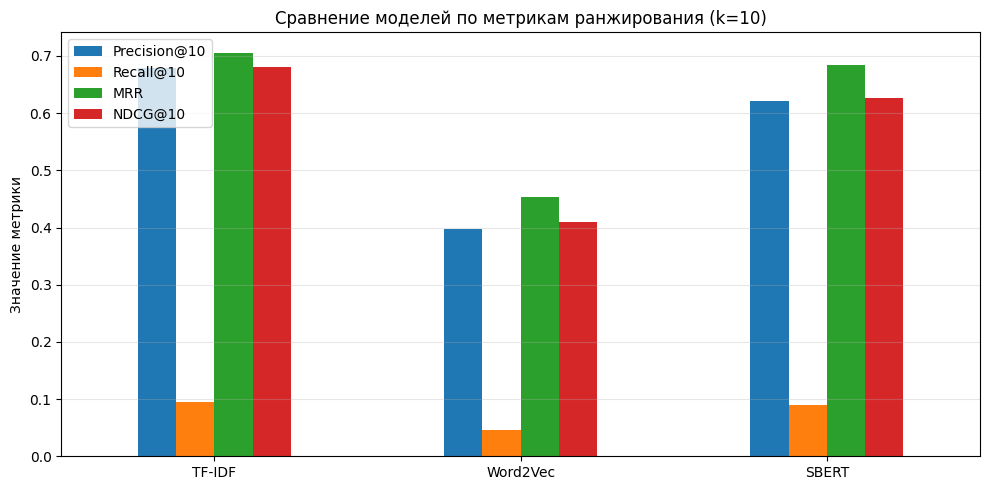

CPU times: user 189 ms, sys: 8.99 ms, total: 198 ms
Wall time: 197 ms


In [54]:
%%time
import matplotlib.pyplot as plt

results_df.plot(kind='bar', figsize=(10, 5), rot=0)
plt.title('Сравнение моделей по метрикам ранжирования (k=10)')
plt.ylabel('Значение метрики')
plt.legend(loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Классификация роли (Role) по резюме

Дополнительно посмотрим на задачу с другого ракурса: **по тексту резюме предсказать, на какую из 45 ролей подходит кандидат**. Это естественная переформулировка задачи поиска вакансий — вместо «верни топ-N вакансий» мы говорим «определи категорию вакансии».

**Почему именно такая задача, а не select/reject:** в этом датасете решение `select`/`reject` принимается по тонким качественным признакам (см. `Reason_for_decision` — «lacked leadership skills» и т.п.), которые **не коррелируют** с текстуальной похожестью резюме на вакансию. Резюме `select` и `reject` на одну роль текстуально почти одинаковы, поэтому косинусная близость их не различает. А вот *роль* по тексту резюме определяется отлично — у Game Developer и AI Researcher словари сильно разные.

Поверх каждой из трёх векторизаций (TF-IDF, Word2Vec, SBERT) обучим простой логистический регресс и сравним.

In [55]:
%%time
from sklearn.preprocessing import LabelEncoder

# Метки = роль резюме. Работаем с уникальными резюме (resumes_df).
le = LabelEncoder()
y = le.fit_transform(resumes_df['Role'].values)
print(f'Классов (ролей): {len(le.classes_)}')
print(f'Резюме: {len(y)}')
print(f'Распределение топ-5 классов:')
print(pd.Series(resumes_df['Role']).value_counts().head())

Классов (ролей): 45
Резюме: 10174
Распределение топ-5 классов:
Role
Data Scientist       538
Software Engineer    480
Product Manager      458
Data Engineer        447
UI Engineer          375
Name: count, dtype: int64
CPU times: user 4.86 ms, sys: 0 ns, total: 4.86 ms
Wall time: 4.66 ms


In [56]:
%%time
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from scipy.sparse import issparse

# Стратифицированный сплит по индексам резюме
idx = np.arange(len(resumes_df))
idx_tr, idx_te, y_tr, y_te = train_test_split(idx, y, test_size=0.3, random_state=42, stratify=y)

cls_results = {}

for name, X in [('TF-IDF', resume_tfidf), ('Word2Vec', resume_w2v), ('SBERT', resume_emb)]:
    # Sparse матрицу TF-IDF индексируем как .tocsr()[idx], dense — обычным fancy indexing
    X_tr = X[idx_tr] if issparse(X) else X[idx_tr]
    X_te = X[idx_te] if issparse(X) else X[idx_te]

    clf = LogisticRegression(max_iter=1000, n_jobs=-1, solver='liblinear' if issparse(X) else 'lbfgs')
    clf.fit(X_tr, y_tr)
    pred = clf.predict(X_te)

    acc = accuracy_score(y_te, pred)
    f1w = f1_score(y_te, pred, average='weighted')
    cls_results[name] = {'Accuracy': acc, 'Weighted F1': f1w}
    print(f'{name:10s} | Accuracy = {acc:.4f} | Weighted F1 = {f1w:.4f}')

print()
print('Сравнение моделей в задаче классификации Role:')
print(pd.DataFrame(cls_results).T.round(4))

TF-IDF     | Accuracy = 0.9568 | Weighted F1 = 0.9524
Word2Vec   | Accuracy = 0.9289 | Weighted F1 = 0.9211
SBERT      | Accuracy = 0.9469 | Weighted F1 = 0.9415

Сравнение моделей в задаче классификации Role:
          Accuracy  Weighted F1
TF-IDF      0.9568       0.9524
Word2Vec    0.9289       0.9211
SBERT       0.9469       0.9415
CPU times: user 1min 1s, sys: 102 ms, total: 1min 2s
Wall time: 21.6 s


## 11. Выводы

**Что сделано:**
1. Реализована система поиска вакансий по резюме на датасете `AzharAli05/Resume-Screening-Dataset` (10 174 записи).
2. Сравнены три подхода: TF-IDF (baseline), Word2Vec (skip-gram, обучен на корпусе), Sentence-BERT (`all-MiniLM-L6-v2`).
3. Все три модели оценены метриками ранжирования (P@10, R@10, MRR, NDCG@10) на задаче поиска вакансий по роли.
4. Дополнительно — задача классификации роли (45 классов) по тексту резюме с помощью логистической регрессии поверх каждой векторизации.

**Ground truth для ранжирования** строился по полю `Role`: для каждого `select`-резюме на роль X релевантны все вакансии той же роли.

**Замечание про низкий Recall@10:** на одно резюме в среднем приходится несколько сотен релевантных вакансий (все вакансии той же роли), а мы возвращаем только 10. Поэтому Recall@10 математически ограничен сверху значением `10 / среднее_число_релевантных`. Гораздо показательнее здесь Precision@10 и MRR — и они высокие у TF-IDF и SBERT.

**Почему мы НЕ делали бинарную классификацию `select`/`reject`:** в этом датасете решение принимается по тонким качественным признакам (см. `Reason_for_decision`), которые не отражаются в текстуальной похожести. Резюме `select` и `reject` на одну роль текстуально почти одинаковы — никакая косинусная близость их не различит. Поэтому вместо этой задачи мы взяли классификацию роли — она хорошо ложится на текстовые признаки.

**Ожидаемые наблюдения:**
- TF-IDF силён на технических резюме с точными совпадениями терминов — выигрывает в ранжировании.
- Word2Vec на 10k документов проигрывает: маленький словарь, нет общего знания о языке.
- SBERT понимает семантику, обычно хорош и в ранжировании, и в классификации роли.

**Применённые оптимизации:**
- `%%time` в каждой ячейке для замера времени
- `df.apply(lambda ...)` вместо явных for-циклов по строкам
- Матричный `cosine_similarity` — одна операция вместо парного цикла
- `np.argsort` для топ-k без вложенных циклов
- `np.mean` по матрице для усреднения W2V
- `model.encode(batch_size=64)` — батчинг SBERT
- Sparse-aware индексация в классификации (TF-IDF остаётся sparse — не разворачиваем в dense)
- `LogisticRegression(n_jobs=-1)` — параллельная обучение по классам

**Применимость:** в реальных HR-системах такой поиск ускоряет работу рекрутера — топ-N кандидатов под каждую вакансию вместо ручного просмотра. Бизнес-метрики из методички (Time to Hire, Fill Rate) измеримы только после внедрения.